# Week 1 Jupyter Notebook
## Linear Regression 1

### Marketing Conversion Propensity Project

The goal of this project is to analyze marketing and product performance data and identify which variables are associated with higher conversion outcomes.

For Week 1, this notebook applies linear regression concepts including continuous features, categorical features, polynomial terms, interaction terms, multicollinearity, variance inflation factor, and regression modeling.

The target variable for this analysis is Conversions.

In [47]:
%pip install scikit-learn statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [49]:
df = pd.read_csv("marketing_and_product_performance.csv")

df.head()

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [50]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Dataset shape:
(10000, 17)

Column names:
Index(['Campaign_ID', 'Product_ID', 'Budget', 'Clicks', 'Conversions',
       'Revenue_Generated', 'ROI', 'Customer_ID', 'Subscription_Tier',
       'Subscription_Length', 'Flash_Sale_ID', 'Discount_Level', 'Units_Sold',
       'Bundle_ID', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund',
       'Common_Keywords'],
      dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Campaign_ID                        10000 non-null  str    
 1   Product_ID                         10000 non-null  str    
 2   Budget                             10000 non-null  float64
 3   Clicks                             10000 non-null  int64  
 4   Conversions                        10000 non-null  int64  
 5   Revenue_Generated                  10000 non-n

In [51]:
df.isnull().sum()

Campaign_ID                          0
Product_ID                           0
Budget                               0
Clicks                               0
Conversions                          0
Revenue_Generated                    0
ROI                                  0
Customer_ID                          0
Subscription_Tier                    0
Subscription_Length                  0
Flash_Sale_ID                        0
Discount_Level                       0
Units_Sold                           0
Bundle_ID                            0
Bundle_Price                         0
Customer_Satisfaction_Post_Refund    0
Common_Keywords                      0
dtype: int64

In [52]:
df = df.dropna()

In [53]:
continuous_features = [
    "Budget",
    "Clicks",
    "Revenue_Generated",
    "ROI",
    "Subscription_Length",
    "Discount_Level",
    "Units_Sold",
    "Bundle_Price",
    "Customer_Satisfaction_Post_Refund"
]

X_continuous = df[continuous_features]
y = df["Conversions"]

In [54]:
categorical_features = [
    "Subscription_Tier"
]

X_categorical = pd.get_dummies(
    df[categorical_features],
    drop_first=True
)

X_categorical.head()

,Subscription_Tier_Premium,Subscription_Tier_Standard
0,True,False
1,True,False
2,False,False
3,True,False
4,False,True


In [55]:
X = pd.concat(
    [X_continuous, X_categorical],
    axis=1
)

X.head()

,Budget,Clicks,Revenue_Generated,ROI,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund,Subscription_Tier_Premium,Subscription_Tier_Standard
0,41770.45,4946,15520.09,1.94,4,43,34,433.80,4,True,False
1,29900.93,570,30866.17,0.76,4,28,97,289.29,2,True,False
2,22367.45,3546,32585.62,1.41,9,51,160,462.87,4,False,False
3,29957.54,2573,95740.12,3.32,32,36,159,334.16,1,True,False
4,36277.19,818,81990.43,3.53,29,20,52,371.67,2,False,True


In [56]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [57]:
# Linear Regression Model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Linear Regression R2:", r2)
print("Linear Regression RMSE:", rmse)

Linear Regression R2: -0.0002778103231264595
Linear Regression RMSE: 291.000684367925


In [58]:
# Regression coefficients

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coef_df.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
8,Customer_Satisfaction_Post_Refund,1.505202
4,Subscription_Length,0.137302
6,Units_Sold,0.066360
1,Clicks,0.002927
2,Revenue_Generated,-0.000031
0,Budget,-0.000409
7,Bundle_Price,-0.039130
5,Discount_Level,-0.326631
3,ROI,-1.160269
9,Subscription_Tier_Premium,-4.820856


In [59]:
# Polynomial terms and interaction terms

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly = poly.fit_transform(X)

poly_feature_names = poly.get_feature_names_out(X.columns)

X_poly_df = pd.DataFrame(
    X_poly,
    columns=poly_feature_names
)

X_poly_df.head()

,Budget,Clicks,Revenue_Generated,ROI,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund,Subscription_Tier_Premium,...,Bundle_Price^2,Bundle_Price Customer_Satisfaction_Post_Refund,Bundle_Price Subscription_Tier_Premium,Bundle_Price Subscription_Tier_Standard,Customer_Satisfaction_Post_Refund^2,Customer_Satisfaction_Post_Refund Subscription_Tier_Premium,Customer_Satisfaction_Post_Refund Subscription_Tier_Standard,Subscription_Tier_Premium^2,Subscription_Tier_Premium Subscription_Tier_Standard,Subscription_Tier_Standard^2
0,41770.45,4946.0,15520.09,1.94,4.0,43.0,34.0,433.80,4.0,1.0,...,188182.4400,1735.20,433.80,0.00,16.0,4.0,0.0,1.0,0.0,0.0
1,29900.93,570.0,30866.17,0.76,4.0,28.0,97.0,289.29,2.0,1.0,...,83688.7041,578.58,289.29,0.00,4.0,2.0,0.0,1.0,0.0,0.0
2,22367.45,3546.0,32585.62,1.41,9.0,51.0,160.0,462.87,4.0,0.0,...,214248.6369,1851.48,0.00,0.00,16.0,0.0,0.0,0.0,0.0,0.0
3,29957.54,2573.0,95740.12,3.32,32.0,36.0,159.0,334.16,1.0,1.0,...,111662.9056,334.16,334.16,0.00,1.0,1.0,0.0,1.0,0.0,0.0
4,36277.19,818.0,81990.43,3.53,29.0,20.0,52.0,371.67,2.0,0.0,...,138138.5889,743.34,0.00,371.67,4.0,0.0,2.0,0.0,0.0,1.0


In [60]:
# Train-test split for polynomial model

X_train_poly, X_test_poly, y_train, y_test = train_test_split(
    X_poly_df,
    y,
    test_size=0.20,
    random_state=42
)

In [61]:
# Polynomial regression model

poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

poly_pred = poly_model.predict(X_test_poly)

poly_r2 = r2_score(y_test, poly_pred)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_pred))

print("Polynomial Regression R2:", poly_r2)
print("Polynomial Regression RMSE:", poly_rmse)

Polynomial Regression R2: -0.003927657362583048
Polynomial Regression RMSE: 291.5311074539903


In [62]:
# Interaction terms only

interaction = PolynomialFeatures(
    degree=2,
    interaction_only=True,
    include_bias=False
)

X_interaction = interaction.fit_transform(X)

interaction_feature_names = interaction.get_feature_names_out(X.columns)

X_interaction_df = pd.DataFrame(
    X_interaction,
    columns=interaction_feature_names
)

X_interaction_df.head()

,Budget,Clicks,Revenue_Generated,ROI,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund,Subscription_Tier_Premium,...,Units_Sold Bundle_Price,Units_Sold Customer_Satisfaction_Post_Refund,Units_Sold Subscription_Tier_Premium,Units_Sold Subscription_Tier_Standard,Bundle_Price Customer_Satisfaction_Post_Refund,Bundle_Price Subscription_Tier_Premium,Bundle_Price Subscription_Tier_Standard,Customer_Satisfaction_Post_Refund Subscription_Tier_Premium,Customer_Satisfaction_Post_Refund Subscription_Tier_Standard,Subscription_Tier_Premium Subscription_Tier_Standard
0,41770.45,4946.0,15520.09,1.94,4.0,43.0,34.0,433.80,4.0,1.0,...,14749.20,136.0,34.0,0.0,1735.20,433.80,0.00,4.0,0.0,0.0
1,29900.93,570.0,30866.17,0.76,4.0,28.0,97.0,289.29,2.0,1.0,...,28061.13,194.0,97.0,0.0,578.58,289.29,0.00,2.0,0.0,0.0
2,22367.45,3546.0,32585.62,1.41,9.0,51.0,160.0,462.87,4.0,0.0,...,74059.20,640.0,0.0,0.0,1851.48,0.00,0.00,0.0,0.0,0.0
3,29957.54,2573.0,95740.12,3.32,32.0,36.0,159.0,334.16,1.0,1.0,...,53131.44,159.0,159.0,0.0,334.16,334.16,0.00,1.0,0.0,0.0
4,36277.19,818.0,81990.43,3.53,29.0,20.0,52.0,371.67,2.0,0.0,...,19326.84,104.0,0.0,52.0,743.34,0.00,371.67,0.0,2.0,0.0


In [63]:
# Train-test split for interaction model

X_train_int, X_test_int, y_train, y_test = train_test_split(
    X_interaction_df,
    y,
    test_size=0.20,
    random_state=42
)

In [64]:
# Interaction regression model

interaction_model = LinearRegression()

interaction_model.fit(X_train_int, y_train)

interaction_pred = interaction_model.predict(X_test_int)

interaction_r2 = r2_score(y_test, interaction_pred)
interaction_rmse = np.sqrt(mean_squared_error(y_test, interaction_pred))

print("Interaction Model R2:", interaction_r2)
print("Interaction Model RMSE:", interaction_rmse)

Interaction Model R2: -0.0023873244462611076
Interaction Model RMSE: 291.30737253797196


In [65]:
# Check multicollinearity using correlation matrix

correlation_matrix = X_continuous.corr()

correlation_matrix

,Budget,Clicks,Revenue_Generated,ROI,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund
Budget,1.000000,-0.011231,-0.021471,0.021008,-0.018117,-0.005146,0.015652,-0.002037,-0.000479
Clicks,-0.011231,1.000000,-0.007068,0.018735,0.003168,0.009950,0.016457,0.005504,-0.002995
Revenue_Generated,-0.021471,-0.007068,1.000000,0.007537,0.005017,0.002391,0.008916,-0.003916,-0.002654
ROI,0.021008,0.018735,0.007537,1.000000,0.008581,0.009896,0.008635,0.014740,0.000467
Subscription_Length,-0.018117,0.003168,0.005017,0.008581,1.000000,-0.003587,0.000192,0.005164,-0.006918
Discount_Level,-0.005146,0.009950,0.002391,0.009896,-0.003587,1.000000,0.003550,0.009471,-0.014122
Units_Sold,0.015652,0.016457,0.008916,0.008635,0.000192,0.003550,1.000000,-0.002542,-0.008362
Bundle_Price,-0.002037,0.005504,-0.003916,0.014740,0.005164,0.009471,-0.002542,1.000000,-0.007531
Customer_Satisfaction_Post_Refund,-0.000479,-0.002995,-0.002654,0.000467,-0.006918,-0.014122,-0.008362,-0.007531,1.000000


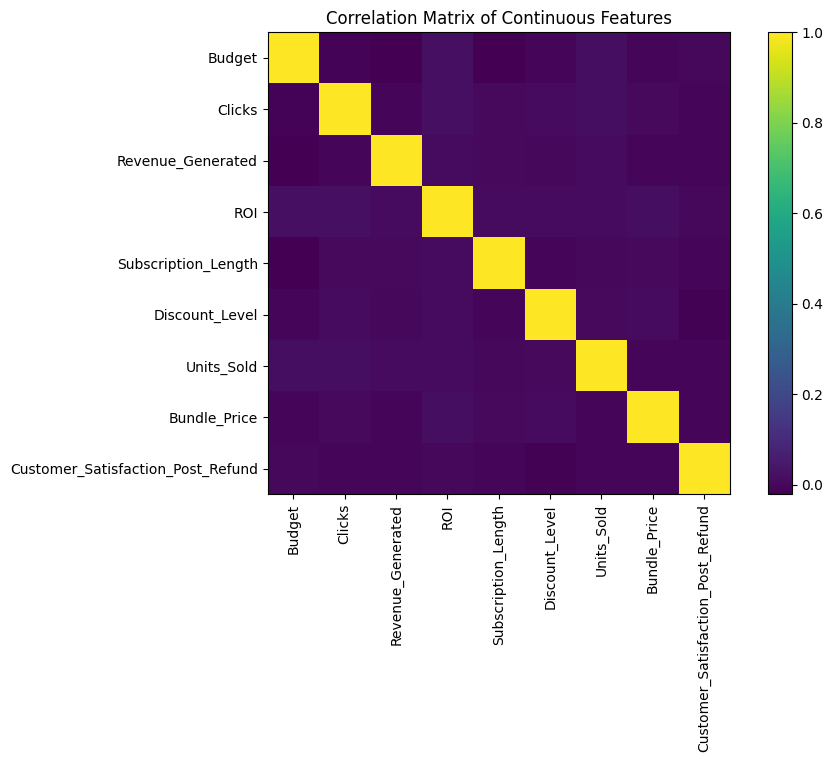

In [66]:
# Plot correlation matrix

plt.figure(figsize=(10, 6))
plt.imshow(correlation_matrix)
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation Matrix of Continuous Features")
plt.show()

In [67]:
# Variance Inflation Factor

X_vif = X_continuous.copy()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data.sort_values(by="VIF", ascending=False)

,Feature,VIF
5,Discount_Level,5.336914
8,Customer_Satisfaction_Post_Refund,5.121114
3,ROI,4.926519
7,Bundle_Price,4.852761
6,Units_Sold,3.782860
4,Subscription_Length,3.777492
0,Budget,3.731435
2,Revenue_Generated,3.713877
1,Clicks,3.679364


In [68]:
# Compare model results

results = pd.DataFrame({
    "Model": [
        "Basic Linear Regression",
        "Polynomial Regression",
        "Interaction Terms Regression"
    ],
    "R2 Score": [
        r2,
        poly_r2,
        interaction_r2
    ],
    "RMSE": [
        rmse,
        poly_rmse,
        interaction_rmse
    ]
})

results

,Model,R2 Score,RMSE
0,Basic Linear Regression,-0.000278,291.000684
1,Polynomial Regression,-0.003928,291.531107
2,Interaction Terms Regression,-0.002387,291.307373


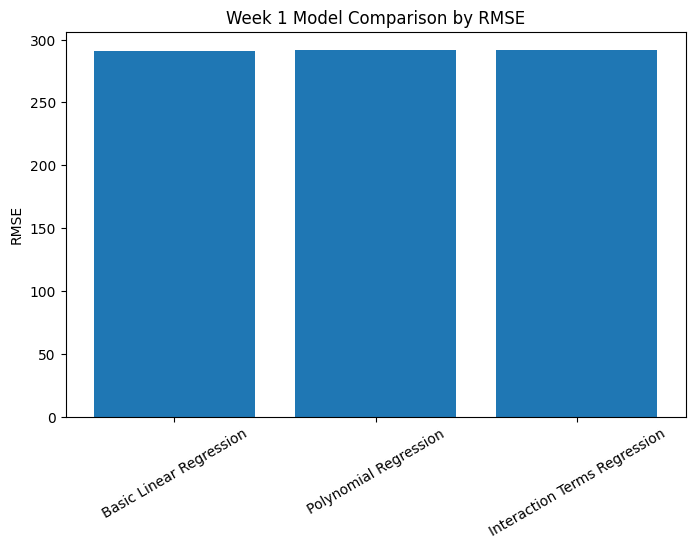

In [69]:
# Plot model comparison by RMSE

plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["RMSE"])
plt.ylabel("RMSE")
plt.title("Week 1 Model Comparison by RMSE")
plt.xticks(rotation=30)
plt.show()

# Conclusion

This Week 1 notebook applied linear regression concepts to the Marketing Conversion Propensity dataset. The target variable was Conversions, and the predictor variables included both continuous and categorical features.

A basic linear regression model was first used to predict conversions from marketing and product performance variables. Categorical features, such as Subscription_Tier, were converted into dummy variables so they could be included in the regression model.

Polynomial terms and interaction terms were then added to test whether nonlinear relationships or combined effects between variables improved model performance. This helped show whether conversion outcomes are influenced by more complex relationships between campaign variables.

Multicollinearity was evaluated using a correlation matrix and Variance Inflation Factor. VIF helped identify whether some predictor variables were highly related to each other, which can make regression coefficients harder to interpret.

Overall, this analysis supports the capstone project by showing how linear regression can be used to study relationships between campaign features and conversion outcomes. The results also show the importance of checking multicollinearity and comparing simple linear models with polynomial and interaction models.